# Proyek Klasifikasi Gambar: Intel_Image_Classification
- **Nama:** Reza Al Pares
- **ID Dicoding:** reza_al_pares_25

## Import Semua Packages/Library yang Digunakan

In [1]:
!unzip Intel_Image_Classification.zip

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: seg_train/seg_train/mountain/7506.jpg  
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain

In [3]:
import os
import tensorflow as tf
import tensorflowjs as tfjs
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Mencetak versi TensorFlow untuk memastikan semuanya siap
print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


## Data Preparation

In [4]:
import os

# Menentukan direktori utama dataset
base_dir = '/content/seg_train/seg_train'

# Memverifikasi kelas yang ada dalam dataset
classes = os.listdir(base_dir)
print(f"Kelas yang ditemukan: {classes}")

Kelas yang ditemukan: ['mountain', 'buildings', 'sea', 'street', 'glacier', 'forest']


### Data Loading

In [5]:
# Augmentasi data untuk melatih model
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    validation_split=0.2 # Pembagian data (Kriteria 3)
)

# Load data training
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Load data validasi
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


### Data Preprocessing

#### Split Dataset

In [6]:
# Inisialisasi ImageDataGenerator dengan augmentasi dan split validasi
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalisasi piksel ke rentang [0,1]
    rotation_range=20,       # Augmentasi rotasi
    horizontal_flip=True,    # Augmentasi flip horizontal
    validation_split=0.2     # Split 20% untuk validasi
)

# Generator untuk data training
train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# Generator untuk data validasi
validation_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


## Modelling

In [10]:
# 1. Load MobileNetV2
base_model = MobileNetV2(input_shape=(150, 150, 3),
                         include_top=False,
                         weights='imagenet')

# 2. Bekukan model dasar
base_model.trainable = False

# 3. Buat model baru
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2), # Dropout biar gak overfit
    layers.Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/tmp/ipykernel_654/3539347518.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(150, 150, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Training

In [11]:
# Callback
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        # Pantau accuracy
        if logs.get('accuracy') > 0.96:
            print("\nTarget akurasi 96% tercapai, stop training!")
            self.model.stop_training = True

callbacks = myCallback()

In [12]:
# Training

history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=[callbacks]
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 303s 845ms/step - accuracy: 0.7985 - loss: 0.5562 - val_accuracy: 0.8770 - val_loss: 0.3575
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 301s 859ms/step - accuracy: 0.8641 - loss: 0.3776 - val_accuracy: 0.8884 - val_loss: 0.3121
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 294s 835ms/step - accuracy: 0.8777 - loss: 0.3394 - val_accuracy: 0.8841 - val_loss: 0.3175
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 302s 858ms/step - accuracy: 0.8786 - loss: 0.3325 - val_accuracy: 0.8916 - val_loss: 0.3172
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 299s 852ms/step - accuracy: 0.8802 - loss: 0.3212 - val_accuracy: 0.8998 - val_loss: 0.2926
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 308s 878ms/step - accuracy: 0.8856 - loss: 0.3073 - val_accuracy: 0.8909 - val_loss: 0.3179
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 299s 851ms/step - accuracy: 0.8822 - loss: 0.3241 - val_accuracy: 0.8959 - val_loss: 0.3203
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 329s 938ms/step - accuracy: 0.8841 -

## Evaluasi dan Visualisasi

In [13]:
import matplotlib.pyplot as plt

# Mengambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))



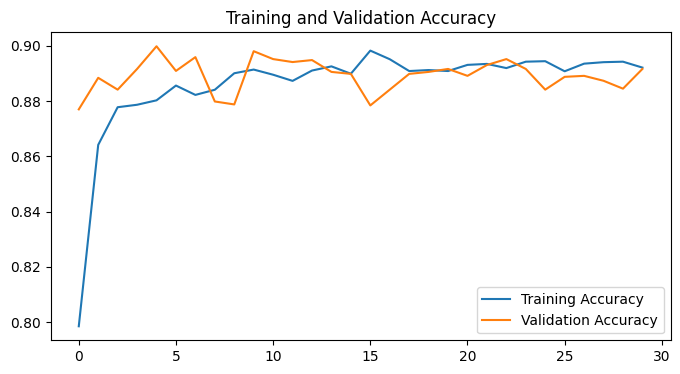

In [14]:
# Memvisualisasi Akurasi
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')
plt.show()

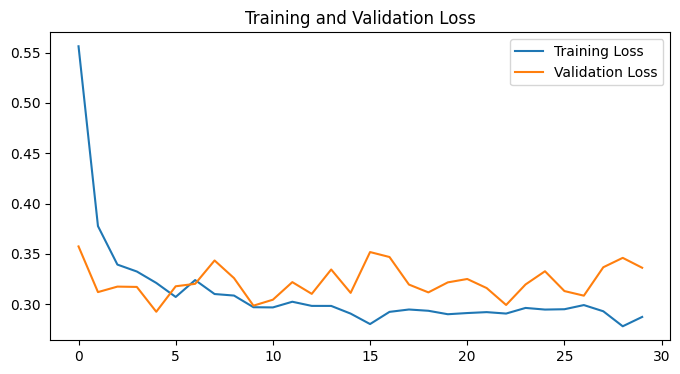

In [15]:
# Visualisasi Loss
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')
plt.show()

## Konversi Model

In [16]:
# Simpan ke format SavedModel
export_dir = 'saved_model/'
tf.saved_model.save(model, export_dir)

print("Model berhasil disimpan ke format SavedModel")

Model berhasil disimpan ke format SavedModel


In [17]:
# Konversi ke TF-Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan file .tflite
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model berhasil dikonversi ke model.tflite")

Saved artifact at '/tmp/tmphi7p1kkd'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  133668277315984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277319056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277316752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277316944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277319632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277319824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277318288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277320400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277320016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133668277317904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1336682773

In [18]:
import tensorflowjs as tfjs

# Simpan ke format TFJS (nanti muncul folder 'tfjs_model')
tfjs.converters.save_keras_model(model, 'tfjs_model')

print("Model berhasil disimpan ke format TFJS")

failed to lookup keras version from the file,
    this is likely a weight only file
Model berhasil disimpan ke format TFJS


## Inference (Optional)

Saving 20108.jpg to 20108.jpg


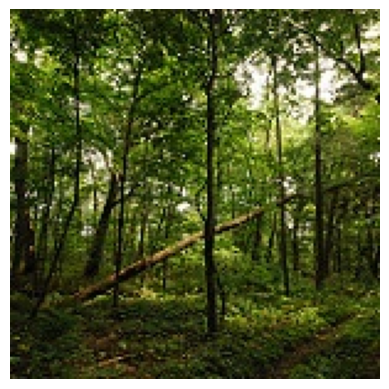

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
File '20108.jpg' diprediksi sebagai: FOREST


In [19]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# Cek apakah variabel model masih ada di RAM, kalau tidak, load dari file lokal
try:
    model
except NameError:
    print("Variabel 'model' hilang dari RAM. Memuat ulang dari model_final.h5...")
    model = load_model('model_final.h5')

# Upload gambar untuk diprediksi
uploaded = files.upload()

# ImageDataGenerator otomatis mengurutkan kelas sesuai abjad (alphabetical order)
class_labels = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

for fn in uploaded.keys():
    # Menyiapkan gambar
    path = fn
    img = image.load_img(path, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Preprocessing gambar
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # Normalisasi

    # Melakukan prediksi
    predictions = model.predict(x)
    predicted_class = class_labels[np.argmax(predictions)]

    print(f"File '{fn}' diprediksi sebagai: {predicted_class.upper()}")

#### Menyusun file

In [22]:
import os
import shutil

os.makedirs('submission/tfjs_model', exist_ok=True)
os.makedirs('submission/tflite', exist_ok=True)
os.makedirs('submission/saved_model', exist_ok=True)

labels = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
with open('submission/tflite/label.txt', 'w') as f:
    f.write('\n'.join(labels))

readme_content = """# Proyek Klasifikasi Gambar - Dicoding
Proyek akhir untuk kelas Belajar Fundamental Deep Learning.
- Arsitektur: Transfer Learning menggunakan MobileNetV2
- Jumlah Kelas: 6 (Buildings, Forest, Glacier, Mountain, Sea, Street)
"""
with open('submission/README.md', 'w') as f:
    f.write(readme_content)

if os.path.exists('tfjs_model'):
    for file in os.listdir('tfjs_model'):
        shutil.move(f'tfjs_model/{file}', f'submission/tfjs_model/{file}')

if os.path.exists('model.tflite'):
    shutil.move('model.tflite', 'submission/tflite/model.tflite')

if os.path.exists('saved_model'):
    for item in os.listdir('saved_model'):
        if item != 'submission':
            shutil.move(f'saved_model/{item}', f'submission/saved_model/{item}')

if os.path.exists('requirements.txt'):
    shutil.move('requirements.txt', 'submission/requirements.txt')

print("Semua file sudah rapi di folder submission!")

Semua file sudah rapi di folder submission!


In [23]:
!zip -r berkas_submission.zip submission/

  adding: submission/ (stored 0%)
  adding: submission/README.md (deflated 24%)
  adding: submission/requirements.txt (deflated 56%)
  adding: submission/tfjs_model/ (stored 0%)
  adding: submission/tfjs_model/group1-shard2of3.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard3of3.bin (deflated 7%)
  adding: submission/tfjs_model/group1-shard1of3.bin (deflated 7%)
  adding: submission/tfjs_model/model.json (deflated 97%)
  adding: submission/saved_model/ (stored 0%)
  adding: submission/saved_model/saved_model.pb (deflated 92%)
  adding: submission/saved_model/assets/ (stored 0%)
  adding: submission/saved_model/variables/ (stored 0%)
  adding: submission/saved_model/variables/variables.index (deflated 77%)
  adding: submission/saved_model/variables/variables.data-00000-of-00001 (deflated 8%)
  adding: submission/saved_model/fingerprint.pb (stored 0%)
  adding: submission/tflite/ (stored 0%)
  adding: submission/tflite/model.tflite (deflated 7%)
  adding: submission/tflite/

#### Menyimpan Requirements

In [24]:
!pip freeze > requirements.txt